In [ ]:
#importar paquetes
#GUARDAR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# =========================
# BLOQUE 0: Carga excel
# =========================
file_path = "HCGO a OSBL - Históricos 2024 2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Data - HCGO")

In [ ]:
# =========================
# BLOQUE 1: Separar 2024 y 2025
# =========================
df_2024 = df.iloc[:, 0:3].copy()
df_2025 = df.iloc[:, 3:6].copy()

df_2024.columns = ["Fecha", "Flujo_U110", "Flujo_Tanques"]
df_2025.columns = ["Fecha", "Flujo_U110", "Flujo_Tanques"]

# Convertir fechas
df_2024["Fecha"] = pd.to_datetime(df_2024["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df_2025["Fecha"] = pd.to_datetime(df_2025["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")

In [ ]:
# =========================
# BLOQUE 2: Merge vertical
# =========================
df_merged = pd.concat([df_2024, df_2025], axis=0)

df_merged = (
    df_merged
    .dropna(subset=["Fecha"])
    .sort_values("Fecha")
    .drop_duplicates(subset="Fecha")
    .set_index("Fecha")
)

In [ ]:
df_merged.head()

,Flujo_U110,Flujo_Tanques
Fecha,,
2024-01-01 00:00:00,4950.108743,2546.995636
2024-01-01 00:01:00,4939.173038,2402.351822
2024-01-01 00:02:00,4928.237333,2241.653656
2024-01-01 00:03:00,4917.301629,2080.95549
2024-01-01 00:04:00,4906.365924,1920.257324


In [ ]:
# =========================
# BLOQUE 3: Suma con indentación de NaN
# =========================

# Convertir a numérico textos como "No Good Data For Calculation" = NaN
#columna auxiliar para Flujo_U110
df_merged["Flujo_U110_num"] = pd.to_numeric(df_merged["Flujo_U110"], errors="coerce")
#columna auxiliar para Flujo_Tanques
df_merged["Flujo_Tanques_num"] = pd.to_numeric(df_merged["Flujo_Tanques"], errors="coerce")

# Identificar entradas problemáticas:
# 1) No numéricas (NaN)
# 2) Negativos
mask_problem = (
    df_merged["Flujo_U110_num"].isna() |
    df_merged["Flujo_Tanques_num"].isna() |
    (df_merged["Flujo_U110_num"] < 0) |
    (df_merged["Flujo_Tanques_num"] < 0)
)

# Crear columna suma condicional:
df_merged["Flujo_Total_HCGO"] = (
    df_merged["Flujo_U110_num"] + df_merged["Flujo_Tanques_num"]
)

# Indentar resultado de suma por NaN (entradas problemáticas)
df_merged.loc[mask_problem, "Flujo_Total_HCGO"] = np.nan

In [ ]:
# =========================
# BLOQUE 4: Preparar datos para graficar
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Convertir a numérico y forzar negativos a NaN
for col in ["Flujo_U110", "Flujo_Tanques", "Flujo_Total_HCGO"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

In [ ]:
# =========================
# BLOQUE 5.0: Mediana por columna (vector independiente)
# =========================

# Asegurar numérico y negativos como NaN
df_merged["Flujo_U110"] = pd.to_numeric(df_merged["Flujo_U110"], errors="coerce")
df_merged["Flujo_Tanques"] = pd.to_numeric(df_merged["Flujo_Tanques"], errors="coerce")
df_merged["Flujo_Total_HCGO"] = pd.to_numeric(df_merged["Flujo_Total_HCGO"], errors="coerce")

df_merged.loc[df_merged["Flujo_U110"] < 0, "Flujo_U110"] = np.nan
df_merged.loc[df_merged["Flujo_Tanques"] < 0, "Flujo_Tanques"] = np.nan
df_merged.loc[df_merged["Flujo_Total_HCGO"] < 0, "Flujo_Total_HCGO"] = np.nan

# Medianas individuales
mediana_U110 = df_merged["Flujo_U110"].median(skipna=True)
mediana_Tanques = df_merged["Flujo_Tanques"].median(skipna=True)
mediana_Total = df_merged["Flujo_Total_HCGO"].median(skipna=True)

print("Mediana Flujo_U110:", mediana_U110)
print("Mediana Flujo_Tanques:", mediana_Tanques)
print("Mediana Flujo_Total_HCGO:", mediana_Total)

Mediana Flujo_U110: 4550.098577878851
Mediana Flujo_Tanques: 4602.086725463867
Mediana Flujo_Total_HCGO: 8560.70064164298


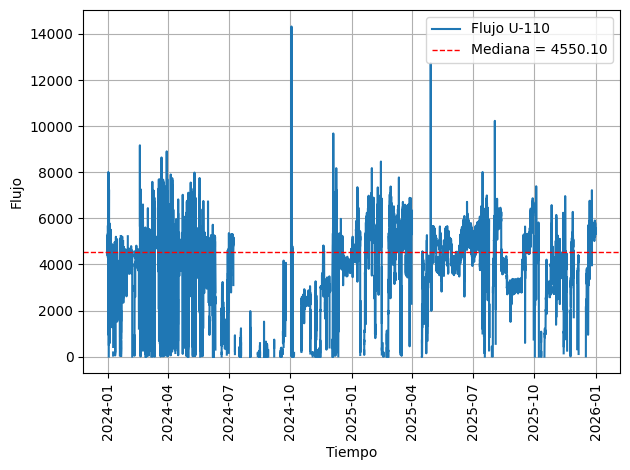

In [14]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo U110
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_U110"], label="Flujo U-110")

plt.axhline(mediana_U110, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_U110:.2f}")

plt.xlabel("Tiempo")
plt.ylabel("Flujo")
plt.xticks(rotation=90)
#plt.title("ACA EL TITULITO")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

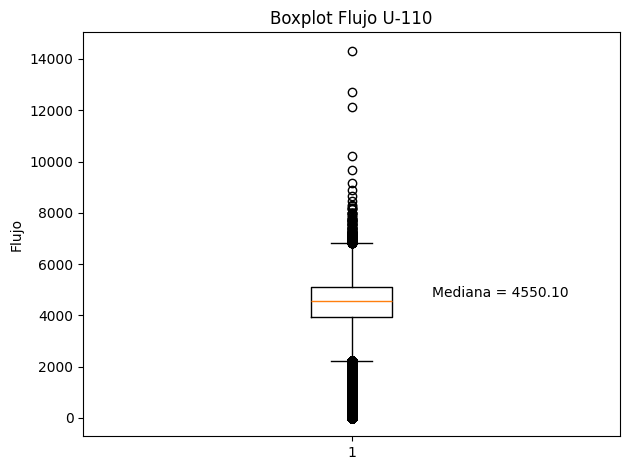

In [ ]:
data_U110 = df_merged["Flujo_U110"].dropna()

plt.boxplot(data_U110, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

plt.text(1.15, mediana_U110 + 0.02*(ymax - ymin),
         f"Mediana = {mediana_U110:.2f}",
         verticalalignment='center')

plt.ylabel("Flujo")
plt.title("Boxplot Flujo U-110")
plt.tight_layout()
plt.show()

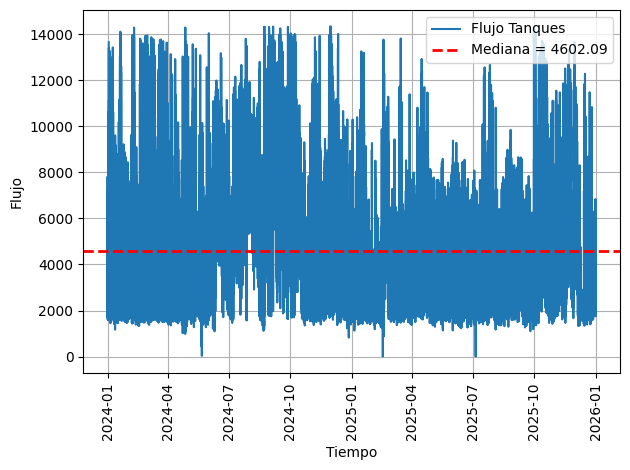

In [ ]:
# =========================
# BLOQUE 5.2: Gráfico discontinuo Flujo Tanques
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Tanques"], label="Flujo Tanques")

plt.axhline(mediana_Tanques, linestyle="--", linewidth=2, color='r',
            label=f"Mediana = {mediana_Tanques:.2f}")

plt.xlabel("Tiempo")
plt.ylabel("Flujo")
plt.xticks(rotation=90)
#plt.title("ACA EL TITULITO")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

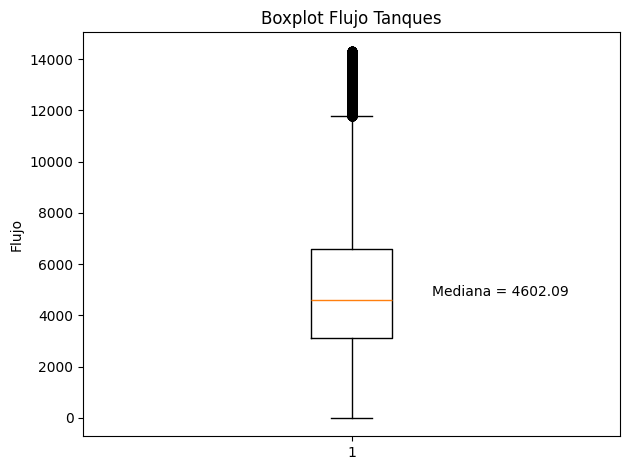

In [18]:
data_Tanques = df_merged["Flujo_Tanques"].dropna()

plt.boxplot(data_Tanques, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

plt.text(1.15, mediana_Tanques + 0.02*(ymax - ymin),
         f"Mediana = {mediana_Tanques:.2f}",
         verticalalignment='center')

plt.ylabel("Flujo")
plt.title("Boxplot Flujo Tanques")
plt.tight_layout()
plt.show()

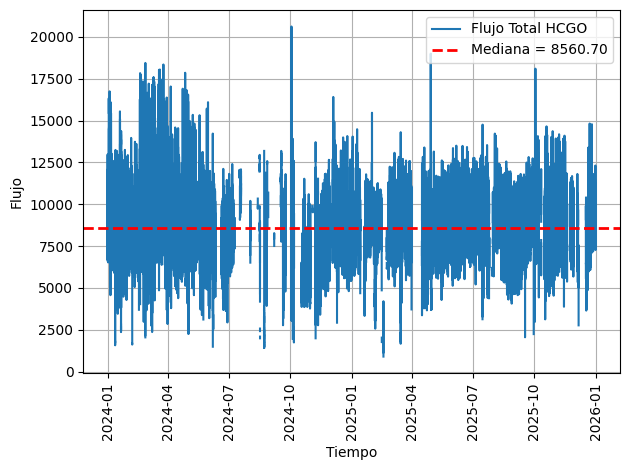

In [ ]:
# =========================
# BLOQUE 5.2: Gráfico discontinuo Flujo Total_HCGO
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Total_HCGO"], label="Flujo Total HCGO")

plt.axhline(mediana_Total, linestyle="--", linewidth=2, color='r',
            label=f"Mediana = {mediana_Total:.2f}")

plt.xlabel("Tiempo")
plt.ylabel("Flujo")
plt.xticks(rotation=90)
#plt.title("ACA EL TITULITO")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

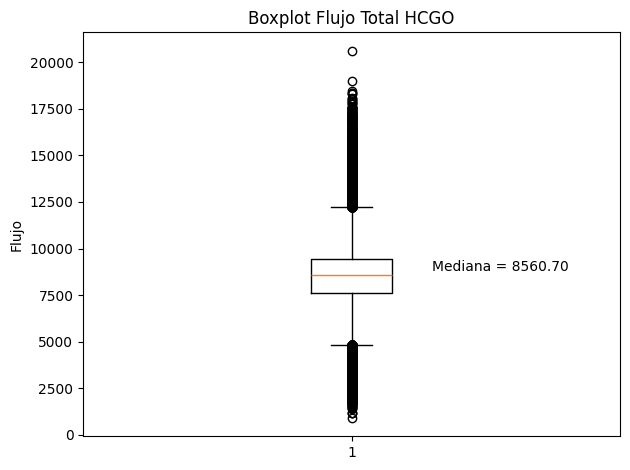

In [21]:
data_Total_HCGO = df_merged["Flujo_Total_HCGO"].dropna()

plt.boxplot(data_Total_HCGO, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

plt.text(1.15, mediana_Total + 0.02*(ymax - ymin),
         f"Mediana = {mediana_Total:.2f}",
         verticalalignment='center')

plt.ylabel("Flujo")
plt.title("Boxplot Flujo Total HCGO")
plt.tight_layout()
plt.show()

In [ ]:
columnas = ["Flujo_U110", "Flujo_Tanques", "Flujo_Total_HCGO"]

# Asegurar formato numérico y negativos como NaN
for col in columnas:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

# Crear columna año desde el índice temporal
df_merged["Año"] = df_merged.index.year

# Calcular medianas por año
medianas_por_año = df_merged.groupby("Año")[columnas].median()

print("Medianas por año:")
print(medianas_por_año)

Medianas por año:
       Flujo_U110  Flujo_Tanques  Flujo_Total_HCGO
Año                                               
2024  4516.690948    5104.085844       8272.575502
2025  4926.361252    4232.608450       8712.481112
